# Project 1. Dimension Reduction Using SVD and PCA

### Student ID: 918589943
### Student Name: CHIYANG CHEN

In [104]:
# All Import Statements Defined Here
# Note: Do not change anything

import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.image import imread

from numpy.linalg import svd
from sklearn.decomposition import PCA
import os
from sklearn.datasets import load_digits

%matplotlib inline

## Part 1. SVD Image Compression

### Load Data (do not change the code !) 

In [105]:
## image1 should be data.png, which is contained in the project zip file
## image2 should be one of your own color photos in png format that you like (you could 
## use a photo of yourself, for instance, but you don't have to) 

image1 = imread(os.getcwd()+'/data.png')
image2 =  imread(os.getcwd()+'/yosemite.png')

image1 = image1[:,:,:3]
image2 = image2[:,:,:3]

## store the images in image_dict with name lake for image1 and name photo for image2

image_dict = {'lake':image1,'photo':image2}

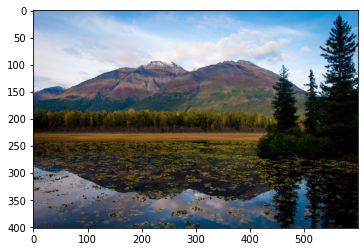

In [106]:
plt.imshow(image_dict['lake'])

In [107]:
image_dict['lake'].shape
## See below for explanation of the dimensions

(402, 600, 3)

So one can think of a digital image as consisting of three layers (one for red (R), one for green (G), and one for blue (B)), and each layer is a matrix (here of size 402 x 600). One can also think of a 3-d matrix, where here the size of the third dimension is very small (only three) as compared to the other two sizes (402 and 600).

<font>I'm Chiyang Chen from China, majored in statistics and on machine learning track. I'm sophmore and one interesting thing about me is that I like mountaineering.</font>

### Write a function to get the compressed matrix

SVD can be used to find lower rank approximations of matrices by setting (small) singular values to zero. More specifically, if $X = s_1u_1v_1^\top＋\ldots+s_du_dv_d^\top$ is the SVD of a matrix (think image), where the singular values $s_k$ are sorted by size $(s_1 \ge s_2 \ge \cdots)$, then we can truncate this sum and use ${\tilde X}_k = s_1u_1v_1^\top＋\ldots+s_ku_kv_k^\top$ with $k<d$ to approximate $X$. Note that the approximation ${\tilde X}_k$ has an SVD with $k$ (non-zero) singular values, and thus the rank of this matrix is $k$ (which is smaller than $d$). This approximation matrix is used as the compressed matrix. This indeed is a compressed matrix, because we only need to store the $k$ vectors $u_1,\ldots,u_k$, the $k$ vectors $v_1,\ldots,v_k$ and the first $k$ singular values, which are $k(1+n+m)$ values as compared to storing the entire matrix. Storing the entire matrix can be done by storing all the elements of the entire SVD, which are $d(1+n+m)$ values, or the original pixels, which are $nm$ values, depending what is smaller. (Note that if $n=m$, then all the pixels are $n^2$ values, while storing the SVD means storing $(2n+1)d \approx 2nd$ values. Thus if the rank $d$ of the matrix is (close to) $n$, then we do not gain anything when storing the SVD, but if $d$ is much less than $n$ (or when compressing the matrix with only using $k$ summands in the SVD with $k$ much less than $n$), then we can gain a lot. Of course, when compressing a matrix (image), we need to make sure that we do not loose too much information, and this is related to the size of the 'small' singular values that are being omitted when doing the compression (see 'reconstruction error' below). 

Now, write a function to implement this compression of the images.

Recommended functions: svd

In [108]:
## First, write a function to compress a matrix; this will then be used to compress an image

def compress_svd(matrix:np.ndarray, k:int) -> np.ndarray:
    """
    use svd to perform matrix compression
    use the svd function from numpy.linalg to perfrom the svd decomposition
    use the first k singular values to reconstruct the compressed matrix
    """
    
    ## write your code here
    U, S, Vt = svd(matrix, full_matrices=False)
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    Vt_k = Vt[:k, :]
    
    compressed_matrix = np.dot(U_k, np.dot(S_k, Vt_k))
    ##end of your code
    
    return compressed_matrix

### Write the following functions to compress the images in two different ways

Each image file has three channels "red", "green" and "blue","RGB", which corresponds to image[:,:,0], image[:,:,1], and image[:,:,2]. The values in image[i,j,0], for instance, are the intensities of the red channel at location (i,j). Now, you need to write two different functions 
- "compress_show_images_reshape" to perform compression by combining the three channels together to a bigger matrix and then decomposing it back to three channels so that it can be displayed as an image again;
- "compress_show_images_separate" to perform compressions on three channels separately. 

Reconstruction error is defined as the mean squared error, i.e., the mean (average) of the squared differences between the entries in the original image tensor and the entries in the compressed image tensor. So if your image tensor has shape (I,J,3), then the sum in the recostruction error extends over all I * J * 3 squared differences.

Recommended functions: imshow, compress_svd

In [109]:
def compress_show_images_reshape(image_name:str, k:int, show_image=True) -> float:
    """
    image_name (string): image name in the image_dict ;
    k (int): number of singular values used for image compression;
    show_image (boolean): whether to plot the compressed images or not;
    
    Concatenate the first three layers of the image tensor into one wide matrix;
    Use compress_svd function to perform svd compression;
    Reshape the wide compressed matrix into an image tensor of three layers;
    If show_image is true, plot the compressed image;
    Put the number of singular values and reconstruction error in the title;
    
    return reconst_error (float), which is the mean squared error of the compressed image
    """
    
    ## your code starts here
        
    image = image_dict[image_name]
    wide_matrix = np.concatenate((image[:,:,0], image[:,:,1], image[:,:,2]), axis=1)
    
    compressed_wide_matrix = compress_svd(wide_matrix, k)
    I, J = image.shape[0], image.shape[1]
    compressed_image = np.zeros(image.shape)
    compressed_image[:,:,0] = compressed_wide_matrix[:, :J]
    compressed_image[:,:,1] = compressed_wide_matrix[:, J:2*J]
    compressed_image[:,:,2] = compressed_wide_matrix[:, 2*J:]
    
    reconst_error = np.mean((image - compressed_image)**2)
    
    if show_image:
        # Plot the compressed image
        plt.imshow(compressed_image)
        plt.title(f'{image_name} - k={k} - reconst. error={reconst_error:.2e}')
        plt.show()
    ## end of your code
    
    return reconst_error

In [110]:
def compress_show_images_separate(image_name:str, k:int, show_image=True) -> float:
    """
    image_name (string): image name in the image_dict;
    k (int): number of singular values used for image compression;
    Show_image (boolean): whether to plot the compressed images or not;
    
    Use compress_svd function to perform svd compression for each of the three layers of the image tensor separately;
    If show_image is true, plot the compressed image;
    Put the number of singular values and reconstruction error in the title;

    return reconst_error (float), which is the mean squared error of the compressed image
    """

    ## your code starts here
    image = image_dict[image_name]
    R,G,B = image[:,:,0], image[:,:,1], image[:,:,2]
    Rc = compress_svd(np.reshape(R,[R.shape[0],R.shape[1]]), k)
    Gc = compress_svd(np.reshape(G,[G.shape[0],G.shape[1]]), k)
    Bc = compress_svd(np.reshape(B,[B.shape[0],B.shape[1]]), k)
    
    compressed_image = np.stack((Rc, Gc, Bc), axis=2)
    
    reconst_error = np.mean((image - compressed_image)**2)
    
    if show_image:
        # Plot the compressed image
        plt.imshow(compressed_image)
        plt.title(f'{image_name} - k={k} - reconst. error={reconst_error:.2e}')
        plt.show()
    
    ## end of your code
    
    return reconst_error



### Write a function to plot the reconstruction errors and their differences 

Compare and visualize the reconstruction errors (see above). Recommended functions to use: matplotlib.pyplot, subplot.

In [111]:
def plot_error(image_name: str, k_min: int, k_max: int):
    """
    image_name (string): image name in the image_dict ;
    k_min (int): minimum number of singular values used for image compression;
    k_max (int): maximum number of singular values used for image compression;

    Plot the reconstruction errors using k ranging from k_min to k_max;
    Use a blue line to indicate the reconstruction error using compress_show_images_reshape function;
    Use a orange line to indicate the reconstruction error using compress_show_images_separate function;
    In a separate subfigure, plot the difference of the reconstruction errors for each k between k_min and k_max

    """

    ## your code starts here
    reshape_errors = []
    separate_errors = []

    # reconstruction errors
    for k in range(k_min, k_max + 1):
        reshape_error = compress_show_images_reshape(image_name, k, show_image=False)
        separate_error = compress_show_images_separate(image_name, k, show_image=False)
        reshape_errors.append(reshape_error)
        separate_errors.append(separate_error)
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(range(k_min, k_max + 1), reshape_errors, label='Reshape method')
    plt.plot(range(k_min, k_max + 1), separate_errors, label='Separate method')
    plt.xlabel('k')
    plt.ylabel('Reconstruction error')
    plt.title(f'Reconstruction errors for {image_name}')
    plt.legend()

    # differences between the reconstruction errors
    error_diffs = [r - s for r, s in zip(reshape_errors, separate_errors)]
    
    plt.subplot(2, 1, 2)
    plt.plot(range(k_min, k_max + 1), error_diffs)
    plt.xlabel('k')
    plt.ylabel('Difference in reconstruction errors')
    plt.title(f'Difference in reconstruction errors for {image_name}')
    plt.tight_layout()
    plt.show()
    ## end of your code


Make some exploratory plots (do not include it in your final submission). Describe briefly what you find (is one error always smaller than the other? is the difference monotonic?)

The larger the k is, the smaller the reconstruction errors are, this make sense since more information is reserved. The separate method seems to make less error than the reshape method monotonically. This also make sense since the important feature(rgb) is reseved during the compression process.

## <font color="Red"> Run the following code.</font> (do not change the code!)

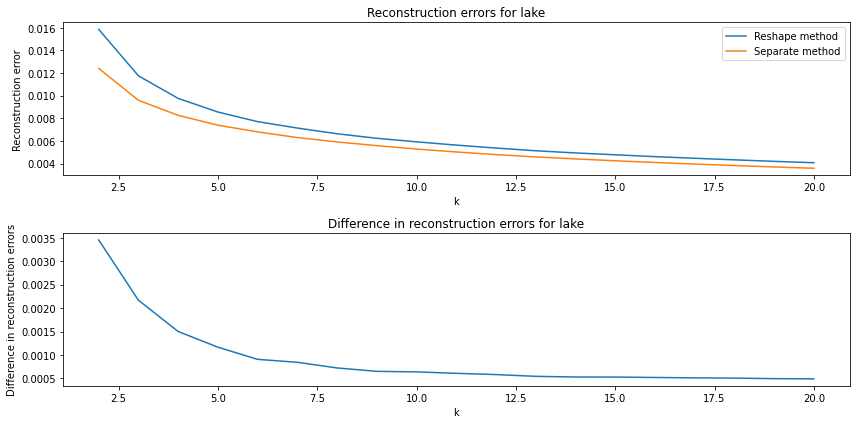

In [112]:
plot_error('lake', 2, 20)

In [113]:
[compress_show_images_separate('lake', k, False) for k in [1,5,10,20,30,40,20000]]

[0.018221032,
 0.0073899403,
 0.005279084,
 0.0035794622,
 0.0027349214,
 0.0021811174,
 2.3733579e-14]

In [114]:
[compress_show_images_reshape('lake', k, False) for k in [1,5,10,20,30,40,20000]]

[0.021424817058367688,
 0.008555698912482604,
 0.005917929392900768,
 0.004069458335699692,
 0.0031915255605649323,
 0.0025949620116139565,
 2.382186801993645e-14]

In [115]:
from ipywidgets import interact

In [116]:
interact(compress_show_images_reshape,image_name=['lake','photo'], k=(10,70))

interactive(children=(Dropdown(description='image_name', options=('lake', 'photo'), value='lake'), IntSlider(v…

<function __main__.compress_show_images_reshape(image_name: str, k: int, show_image=True) -> float>

## Part 2. PCA of hand-written digits

### Load data

The data we are going to work with are hand-writted digits data. The digits data available in sklearn consists of 1797 images of handwritten digits, each image consisting of  8×8=64  pixels. We can think of the digits to consist of 10 classes (one class for each of the digits 0 - 9). Indeed, the data set comes with labels 0-9, indicating the figure it represents ("digits.target" gives you these labels as an array), although when performaing PCA we are ignoring the labels ("unsupervised"). We only use the labels to make vizualising the results more effective. In the following code, change the value of the index to plot different images.

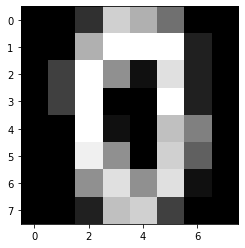

In [117]:
index = 20
digits = load_digits()
plt.imshow(digits.images[index],cmap='gray') 
# target = digits.target

In [118]:
# To see the size of the data set

digits.data.shape

(1797, 64)

### Check the covariance matrix

Notice that in contrast to the first part of this project, we here have many images, and we consider each image as a data point. To this end we consider each image, i.e. each $(8 \times 8)$-matrix representing the image, as a vector (a 'stringed' matrix) of length $8 \times 8 = 64$. So our data are now 64-dimensional vectors, and we have 1797 such data points. 

The following code computes the covariance matrix of these data vectors and gets its rank. 

In [119]:
mu=digits.data.mean(axis=0)
X=digits.data
X_bar=np.repeat(mu,X.shape[0]).reshape(len(mu),-1).T
cov=np.dot( (X-X_bar).T, X-X_bar )

np.linalg.matrix_rank(cov)


61

So, in the above code, X is our $(1797 \times 64)$ data matrix, where each row is one of the images considered as a $64$-dimensional vector. X_bar is the 64-dimensional vector of averages (taken over the 1797 vectors) of each of the components of the vector, so that np.cdot(X-X_bar.T X-X_bar) is the covariance matrix of our 64-dimensional data cloud. Interpret what you have found above.

### Now use PCA to find a 2-dim subspace to reconstruct the digits 

Here we first perform dimension reduction of our 64-dimensional data. The goal is to reduce the dimension to 2, and we want to use PCA for that. Then we 'reconstruct' the data by finding the approximation to the original image (or vector in 64-dimensional space).  To this end, we find the first two principal components (i.e. the first two principal component loading vectors) and use them together with the correponding principal component scores to reconstruct the digits image. Formally, if $w_1,\ldots,w_p$ denote the principal component loading vectors, or the principal axis (recall that the form a basis of unit eigenvectors of the covariance matrix), then each $p$-dimensional data vector $X$ can be written as

$$X = \sum_{j=1}^p w_j Z_{j}$$

where $Z_{j} = \langle w_j,X \rangle$ is the projection score of $X$ when projected on $w_j$. The 'reconstruction' $X^{(k)}_{\rm inv}$ of $X$ based on $k \le p$ principal component axis is

$$X^{(k)}_{\rm inv} = \sum_{j=1}^k w_j Z_{j}.$$

The index 'inv' stands for *inverse* (so we try to approximate the inverse map: from the principal axes (loadings) and principal component scores (or projection scores) back to the data). You don't have to implement the reconstruction yourself. Just use the corresponding recommended function that comes with the PCA function from scikit-learn (sklearn).

Recommend functions: PCA, transform, inverse_transform

In [120]:
## X_new is a list of lists which contains the first two PC for each digit image
## X_inv is the reconstructed digit image with the same shape as X
## set the random_state = 12 for the PCA function(!) this is important for your grade.

## your code starts here


# PCA with 2 principal components
pca = PCA(n_components=2, random_state=12)
X_pca = pca.fit_transform(X)

# Reconstruct the data
X_inv = pca.inverse_transform(X_pca)




## end here

### Plot each digit (elements in X_new) with different color labels

Make a scatter plot of the first two pc scores and mark each point with different color that corresponds to its label, 0~9.

Recommended functions: plt.scatter

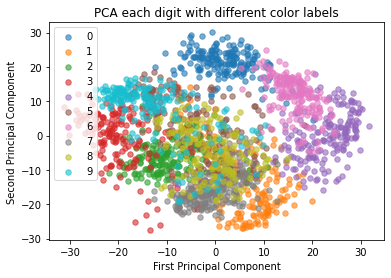

In [121]:
## your code starts here

labels = digits.target

for i in range(10):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=str(i), alpha=0.6, s=30)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend()
plt.title('PCA each digit with different color labels')
plt.show()

## end here

In [122]:
X_pca

array([[ -1.25946683,  21.27488099],
       [  7.95761091, -20.76870461],
       [  6.99192352,  -9.95598123],
       ...,
       [ 10.80128525,  -6.96024975],
       [ -4.87210128,  12.42395561],
       [ -0.34438823,   6.36555662]])

### Write a function to do a side-by-side plot of the original digit and the reconstructed digit

The left subplot is the original digit, the right subplot is the reconstructed digit. 'index' is the index of the image we want to reconstruct and plot.

In [123]:
def plot_digits(index:int):
    """
    the left part is the compressed digit, the right part is the original digit
    """
    ## your code starts here

    
    original_digit = X[index].reshape(8, 8)
    reconstructed_digit = X_inv[index].reshape(8, 8)

    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.imshow(original_digit, cmap=plt.cm.gray_r, interpolation='nearest')
    ax1.set_title('Original Digit')
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax2.imshow(reconstructed_digit, cmap=plt.cm.gray_r, interpolation='nearest')
    ax2.set_title('Reconstructed Digit')
    ax2.set_xticks([])
    ax2.set_yticks([])

    plt.show()
    
    
    
    ## end here

## <font color="Red"> Run the following code.</font> (do not change the code!)

In [124]:
X_inv[0]

array([-1.06205207e-15,  1.10626914e-01,  4.44191193e+00,  1.18063215e+01,
        1.07493158e+01,  3.39833625e+00,  5.09920504e-02, -4.20291639e-02,
        2.49610241e-03,  1.69701669e+00,  1.19740914e+01,  1.16788043e+01,
        8.38141400e+00,  7.34547162e+00,  6.11223386e-01,  3.14124548e-02,
        1.94499279e-03,  3.47286485e+00,  1.40160400e+01,  5.68604617e+00,
        2.51564997e+00,  7.91668154e+00,  2.32198152e+00,  4.03119253e-02,
       -2.15810066e-04,  4.02956705e+00,  1.27804312e+01,  5.93137976e+00,
        4.63725756e+00,  8.66603267e+00,  3.63836316e+00,  2.81493730e-03,
        0.00000000e+00,  4.01350990e+00,  9.05748081e+00,  3.10220333e+00,
        4.12475708e+00,  1.22384928e+01,  5.60232331e+00,  0.00000000e+00,
        1.34385175e-02,  2.53046924e+00,  9.27133942e+00,  1.19509350e+00,
        9.92216788e-01,  1.33325823e+01,  8.13131651e+00,  5.34711306e-02,
        1.24618644e-02,  9.39578740e-01,  1.08402535e+01,  6.87893829e+00,
        7.21199881e+00,  

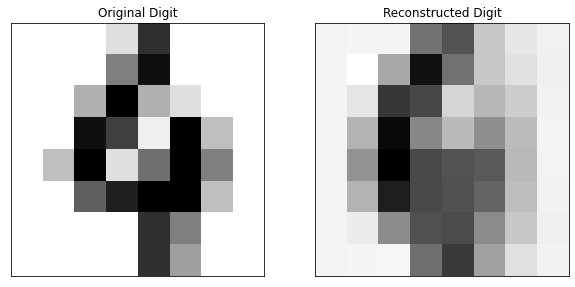

In [125]:
plot_digits(100)